In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import zipfile

In [ ]:
def convert_lat_lon(coord_str):
    """Takes a string like "35.32 S 148.25 E" and returns numerical latitude and longitude.
    Returns (NaN, NaN) for invalid or empty input."""
    # Return null values if the input is not a string (e.g., NaN)
    if not isinstance(coord_str, str):
        return np.nan, np.nan

    try:
        parts = coord_str.split()
        lat_val, lat_dir, lon_val, lon_dir = float(parts[0]), parts[1], float(parts[2]), parts[3]
        # Adjust sign based on hemisphere: S and W are negative
        if lat_dir.upper() == 'S': lat_val = -lat_val
        if lon_dir.upper() == 'W': lon_val = -lon_val
        return lat_val, lon_val
    except (IndexError, ValueError):
        # Handle cases where the string format is incorrect
        return np.nan, np.nan

In [3]:
zip_path = '/usr2/people/macgregor/amplicon/workflow_16s/resources/pangenomes/date_and_latlon_samples_extended.tsv.zip'
tsv_filename_inside_zip = 'date_and_latlon_samples_extended.tsv'

with zipfile.ZipFile(zip_path, 'r') as zf:
    with zf.open(tsv_filename_inside_zip) as tsv_file:
        df = pd.read_csv(tsv_file, sep='\t')
        
df[['ncbi_latitude', 'ncbi_longitude']] = df['ncbi_lat_lon'].apply(lambda x: pd.Series(convert_lat_lon(x)))
df[['latitude', 'longitude']] = df['lat_lon'].apply(lambda x: pd.Series(convert_lat_lon(x)))

In [4]:
nfc_samples_df_path = '/usr2/people/macgregor/amplicon/project_01/.cache/nfc_facilities/03_nearby_samples.pkl'
nfc_samples_df = pd.read_pickle(nfc_samples_df_path)

# Define the threshold for dropping columns (at least 25% non-NA values)
min_data_threshold = len(nfc_samples_df) * 0.25
nfc_samples_df = nfc_samples_df.dropna(thresh=min_data_threshold, axis=1)

In [5]:
# Convert pandas DataFrames to GeoDataFrames
gdf_genomes = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")
gdf_samples = gpd.GeoDataFrame(nfc_samples_df, geometry=gpd.points_from_xy(nfc_samples_df.longitude, nfc_samples_df.latitude), crs="EPSG:4326")

# Project to a CRS that uses meters for accurate distance calculation
gdf_genomes_proj = gdf_genomes.to_crs("EPSG:3857")
gdf_samples_proj = gdf_samples.to_crs("EPSG:3857")

# Set a search radius for nearby genomes
SEARCH_RADIUS_METERS = 50 
# Perform the join, linking each sample to all nearby genomes
analysis_df = gpd.sjoin_nearest(gdf_samples_proj, gdf_genomes_proj,
                                max_distance=SEARCH_RADIUS_METERS,
                                how='left')

# Drop unnecessary columns 
analysis_df = analysis_df.drop(columns=['geometry', 'index_right'])

In [33]:
def tax_richness_by_cat(df, tax_col, cat_col):
    """Calculate taxonomic richness for each category in cat_col based on unique values in tax_col."""
    richness = df.groupby(cat_col)[tax_col].nunique().sort_values(ascending=False).reset_index()
    richness.columns = [cat_col, f'{tax_col}_richness']
    return richness[richness.columns]

In [ ]:
def tax_frequency_by_cat(df, tax_col, cat_col):
    """Calculate the frequency of each taxonomic group within each category.
    
    Args:
    df (pd.DataFrame): The input dataframe containing taxonomic and category columns.
    tax_col (str): The name of the column containing taxonomic groups (e.g., species).
    cat_col (str): The name of the column containing categories (e.g., environment).
    
    Returns:
    pd.DataFrame: A frequency table with taxonomic groups as rows and categories as columns.
    """
    frequency_table = pd.crosstab(df[tax_col], df[cat_col])
    return frequency_table

In [ ]:
from scipy import stats
def chi_square_test(frequency_table, alpha=0.05):
    """Perform Chi-Square test of independence on the frequency table.
    
    Args:
    frequency_table (pd.DataFrame): The frequency table with taxonomic groups as rows and categories as columns.
    
    Returns:
    tuple: Chi-square statistic, p-value, degrees of freedom, and expected frequencies.
    """
    chi2, p, dof, expected = stats.chi2_contingency(frequency_table)
    if p < alpha:
        print("Result: The p-value is less than alpha. We reject the null hypothesis.")
        print("Conclusion: There is a statistically significant association.")
    else:
        print("Result: The p-value is greater than alpha. We fail to reject the null hypothesis.")
        print("Conclusion: There is no statistically significant association.")
    return chi2, p, dof, expected

In [30]:
import numpy as np
def cramers_v(frequency_table, chi2_stat):
    """Calculate Cramér's V to measure the strength of association.
    
    Args:
    frequency_table (pd.DataFrame): The frequency table with taxonomic groups as rows and categories as columns.
    chi2_stat (float): The Chi-square statistic from the Chi-square test.
    
    Returns:
    float: Cramér's V value.
    """
    n = frequency_table.sum().sum() # Total number of observations
    k = min(frequency_table.shape) # Number of rows or columns, whichever is smaller
    cramers_v = np.sqrt(chi2_stat / (n * (k - 1)))
    if cramers_v < 0.1: strength = "negligible"
    elif cramers_v < 0.2: strength = "weak"
    elif cramers_v < 0.4: strength = "moderate"
    elif cramers_v < 0.6: strength = "relatively strong"
    else: strength = "strong"

    print(f"The Cramér's V analysis shows a {strength} association.")
    return cramers_v

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def prevalence_heatmap(analysis_df, tax_col='species', cat_col='experiment_environment_material', width=10, height=12):
    """Generate a heatmap showing the prevalence of each taxonomic group within each category.
    
    Args:
    analysis_df (pd.DataFrame): The dataframe containing taxonomic and category columns.
    tax_col (str): The name of the column containing taxonomic groups (default is 'species').
    cat_col (str): The name of the column containing categories (default is 'experiment_environment_material').
    """
    indicator_table = pd.crosstab(analysis_df[tax_col], analysis_df[cat_col], normalize='columns')
    indicator_table.round(2)
    plt.figure(figsize=(width, height))
    sns.heatmap(indicator_table,
                #annot=True,          # Show the prevalence values in the cells
                cmap='viridis',      # Use the 'viridis' color scheme
                fmt='.2f')           # Format numbers to two decimal places

    plt.title(f"Heatmap of {tax_col.title()} Prevalence in Each {cat_col.replace('_', ' ').title()}")
    plt.ylabel(f'{tax_col.title()}')
    plt.xlabel(f'{cat_col.title()}')
    plt.show()

In [12]:
analysis_df

,#sampleid,biosample_collection_date,biosample_depth,biosample_description,biosample_ena-checklist,biosample_ena-first-public,biosample_ena-last-update,biosample_env_broad_scale,biosample_env_local_scale,biosample_env_medium,...,geographic_location_harmonized,host_harmonized,isolation_source_harmonized,project_name,env_broad_med_local,misc_attributes,ncbi_latitude,ncbi_longitude,latitude_right,longitude_right
0,srr10357667,2015-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,srr10357666,2015-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,srr11712105,2017-04-25,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,srr20039836,2018-07-19,0-5 cm,Soil - bacteria,NaN,NaN,NaN,New Mexico/Colorado high grassland,New Mexico/Colorado high grassland,Soil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,srr6860915,2012-07-03,10cm,DroughtTolerantPinyonSeedling16S,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114314,srr29231888,2021-08,10-30,12_lower_incubation,NaN,NaN,NaN,wetland ecosystem [ENVO:01001209],peatland [ENVO:00000044],acidic soil [ENVO:01001185],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114315,srr23035266,2016-12,0.06,Keywords: GSC:MIxS;MIMARKS:5.0,NaN,NaN,NaN,ENVO:01000196,ENVO:01000211,ENVO:00005784,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114316,srr23035291,2016-12,0.06,Keywords: GSC:MIxS;MIMARKS:5.0,NaN,NaN,NaN,ENVO:01000196,ENVO:01000211,ENVO:00005784,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114317,srr23035277,2016-09,0.06,Keywords: GSC:MIxS;MIMARKS:5.0,NaN,NaN,NaN,ENVO:01000196,ENVO:01000211,ENVO:00005784,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
tax_col = 'phylum'
cat_col = 'run_environment_material'
cat_analysis_df = analysis_df.copy()
cat_analysis_df.dropna(subset=[cat_col], inplace=True)

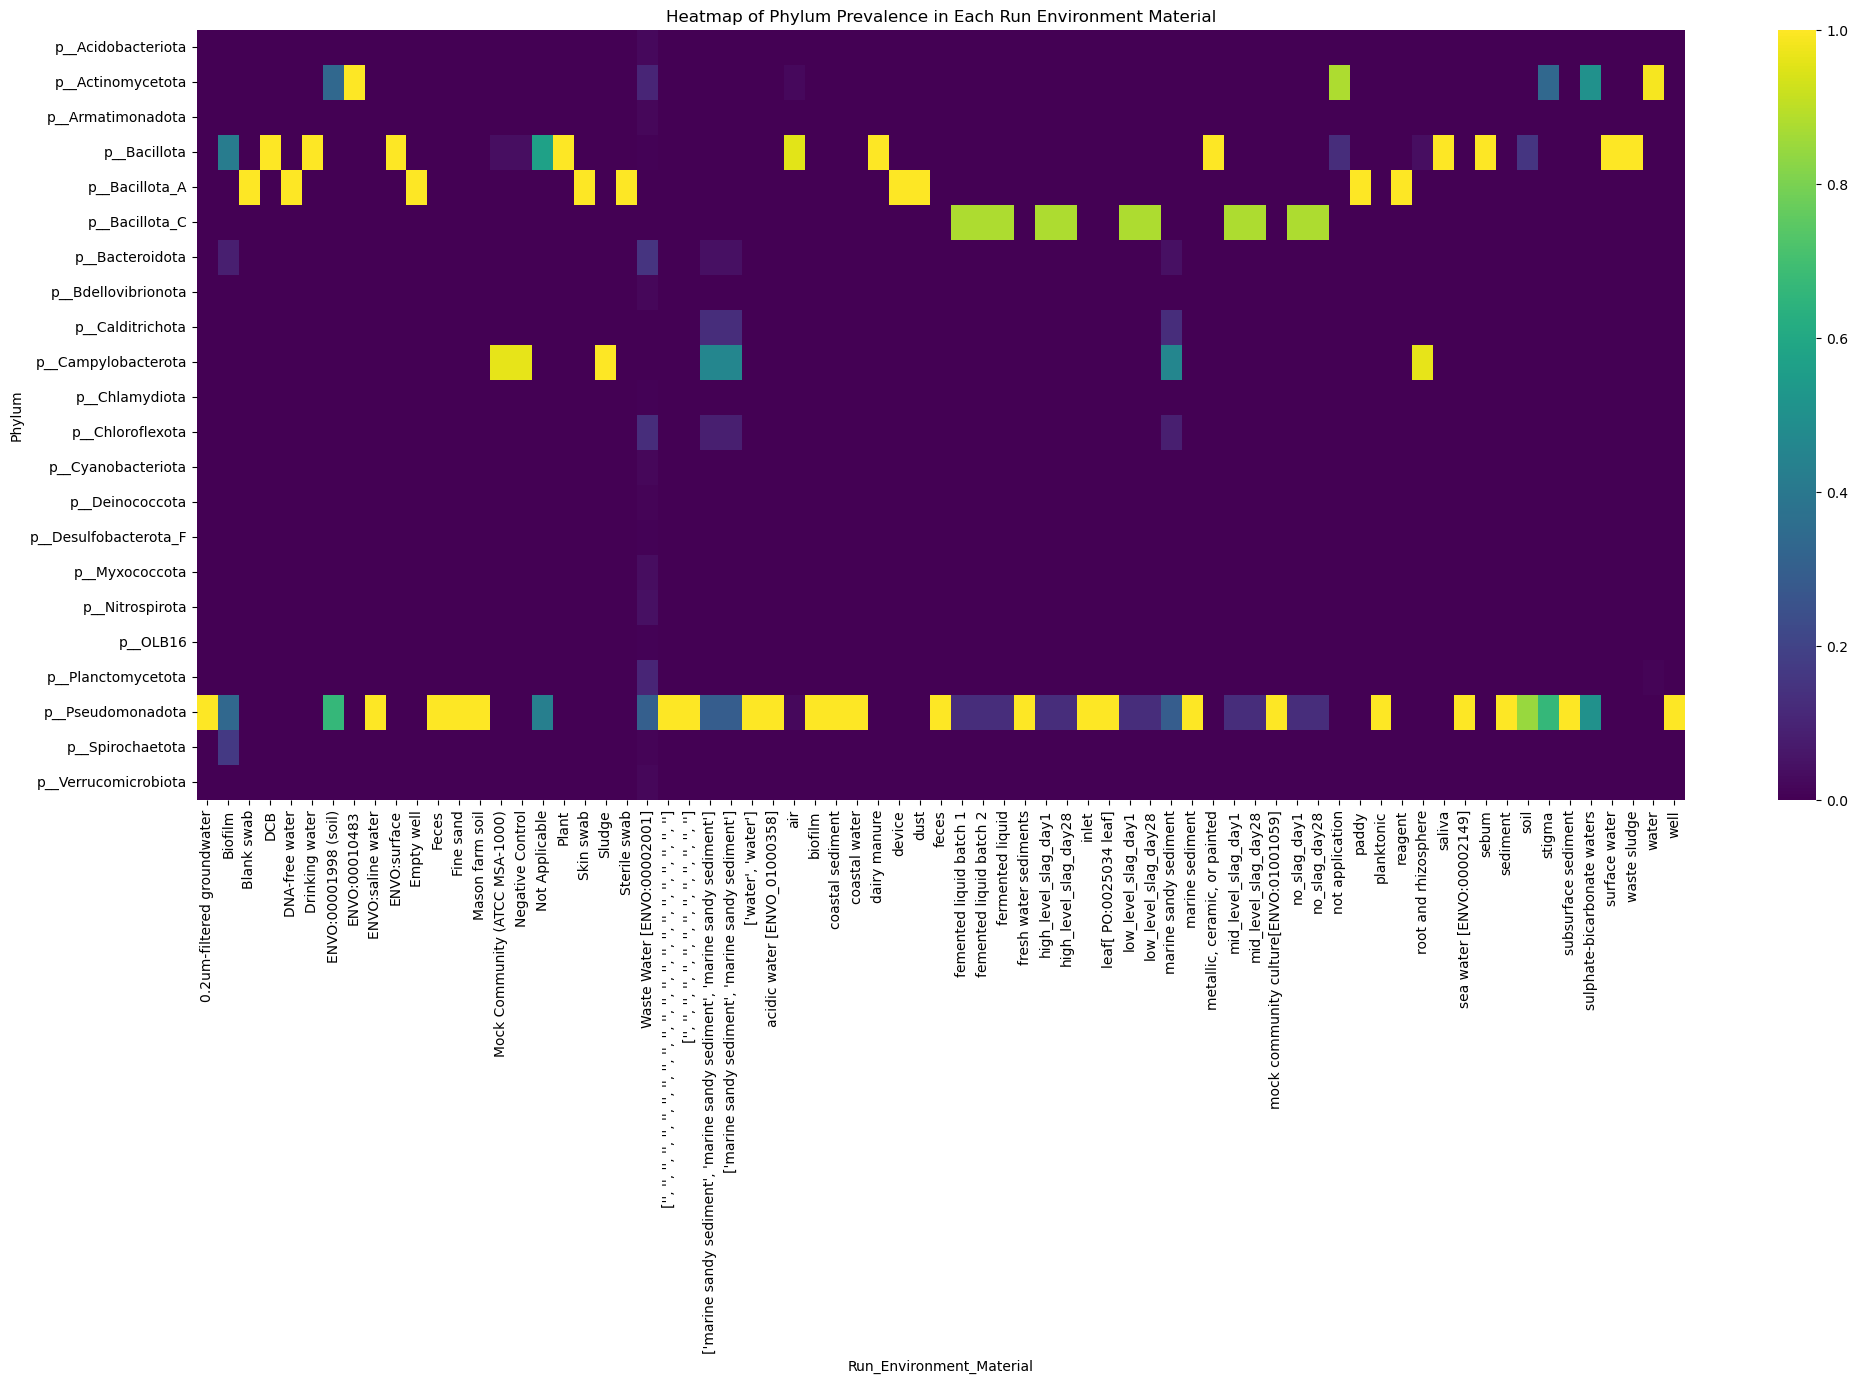

In [45]:
prevalence_heatmap(cat_analysis_df, tax_col, cat_col, 24, 10)

In [46]:
richness = tax_richness_by_cat(cat_analysis_df, tax_col, cat_col)
richness

,run_environment_material,phylum_richness
0,Waste Water [ENVO:00002001],18
1,"['marine sandy sediment', 'marine sandy sedime...",5
2,"['marine sandy sediment', 'marine sandy sedime...",5
3,marine sandy sediment,5
4,Biofilm,4
...,...,...
1351,Gelatine12,0
1352,Gelatine11,0
1353,Gelatine10,0
1354,Gelatine1,0


In [47]:
frequency_table = tax_frequency_by_cat(cat_analysis_df, tax_col, cat_col)
frequency_table

run_environment_material,0.2um-filtered groundwater,Biofilm,Blank swab,DCB,DNA-free water,Drinking water,ENVO:00001998 (soil),ENVO:00010483,ENVO:saline water,ENVO:surface,...,sebum,sediment,soil,stigma,subsurface sediment,sulphate-bicarbonate waters,surface water,waste sludge,water,well
phylum,,,,,,,,,,,,,,,,,,,,,
p__Acidobacteriota,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
p__Actinomycetota,0,0,0,0,0,0,120,9,0,0,...,0,0,0,184,0,4,0,0,12502,0
p__Armatimonadota,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
p__Bacillota,0,5,0,33,0,3204,0,0,0,285,...,33,0,101,0,0,0,31,27,0,0
p__Bacillota_A,0,0,162,0,108,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
p__Bacillota_C,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
p__Bacteroidota,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
p__Bdellovibrionota,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
p__Calditrichota,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [48]:
chi2_stat, p_value, dof, expected = chi_square_test(frequency_table)
cramers_v_value = cramers_v(frequency_table, chi2_stat)

Result: The p-value is less than alpha. We reject the null hypothesis.
Conclusion: There is a statistically significant association.
The Cramér's V analysis shows a relatively strong association.


In [49]:
analysis_df.columns.tolist()

['#sampleid',
 'biosample_collection_date',
 'biosample_depth',
 'biosample_description',
 'biosample_ena-checklist',
 'biosample_ena-first-public',
 'biosample_ena-last-update',
 'biosample_env_broad_scale',
 'biosample_env_local_scale',
 'biosample_env_medium',
 'biosample_external_id',
 'biosample_geo_loc_name',
 'biosample_host',
 'biosample_insdc_center_name',
 'biosample_insdc_first_public',
 'biosample_insdc_last_update',
 'biosample_insdc_secondary_accession',
 'biosample_insdc_status',
 'biosample_isolation_source',
 'biosample_lat_lon',
 'biosample_ncbi_submission_model',
 'biosample_ncbi_submission_package',
 'biosample_organism',
 'biosample_scientific_name',
 'biosample_sra_accession',
 'biosample_submitter_id',
 'biosample_title',
 'experiment_accession',
 'experiment_base_count',
 'experiment_broad_scale_environmental_context',
 'experiment_center_name',
 'experiment_checklist',
 'experiment_collection_date',
 'experiment_collection_date_end',
 'experiment_collection_dat

In [50]:
# --- 1. Create a feature matrix (X) ---
# Each row is a unique sample, each column is a species.
# The values are 1 if the species is present, 0 if absent.
feature_matrix = pd.crosstab(analysis_df['#sampleid'], analysis_df['species'])
print("--- Feature Matrix (Presence/Absence of Species) ---")
print(feature_matrix)

# --- 2. Create the target variable (y) ---
# We need to get the environment_type for each unique sample.
# We'll drop duplicates to get one environment per sampleid.
target_data = analysis_df[['#sampleid', 'experiment_environment_material']].drop_duplicates().set_index('#sampleid')
y = target_data['experiment_environment_material']

# --- 3. Align the feature matrix and target ---
# This ensures the rows (samples) in both X and y are in the same order.
X, y = feature_matrix.align(y, axis=0, join='inner')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 4. Split Data into Training and Testing Sets ---
# Note: With only 4 samples, this split is for demonstration.
# A real project needs much more data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42 # stratify=y has been removed
)

# --- 5. Initialize and Train the Random Forest Model ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- 6. Make Predictions and Evaluate ---
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print(classification_report(y_test, y_pred))

# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_, yticklabels=model.classes_)

--- Feature Matrix (Presence/Absence of Species) ---
species                       s__2-02-FULL-66-14 sp004298295  \
#sampleid                                                      
['srr1576828', 'srr1576831']                               0   
['srr1584481', 'srr1584480']                               0   
['srr1584482', 'srr1584483']                               0   
['srr1584486', 'srr1584485']                               0   
['srr1584503', 'srr1584504']                               0   
...                                                      ...   
srr9715507                                                 0   
srr9715508                                                 0   
srr9715511                                                 0   
srr9715512                                                 0   
srr9715513                                                 0   

species                       s__AAA044-D11 sp009698045  \
#sampleid                                              

ValueError: Input contains NaN

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# 1. Calculate the standard confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

# 2. Normalize the confusion matrix
# This calculates recall: cm[i, j] / sum(cm[i, :])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


# 3. Create the display object with the NORMALIZED matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                              display_labels=model.classes_)

# 4. Plot the matrix and format the values as decimals
# Note that 'normalize' is removed from the plot() call
fig, ax = plt.subplots(figsize=(25, 25)) # Increase figure size
disp.plot(cmap='viridis',
          xticks_rotation='vertical',
          values_format='.2f', # Format values to 2 decimal places
          ax=ax)

plt.tight_layout()
plt.show()

NameError: name 'y_pred' is not defined

/usr2/people/macgregor/miniconda3/envs/workflow_16s/lib/python3.10/site-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/opt/tmp/ipykernel_2141928/779848189.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xlabel(f"PC1 ({pcoa_results.proportion_explained[0]:.2%})")
/opt/tmp/ipykernel_2141928/779848189.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.ylabel(f"PC2 ({pcoa_results.proportion_explained[1]:.2%})")
/opt/tmp/ipykernel_2141928/779848189.py:46: UserWarning: Tight layout not applied. Th

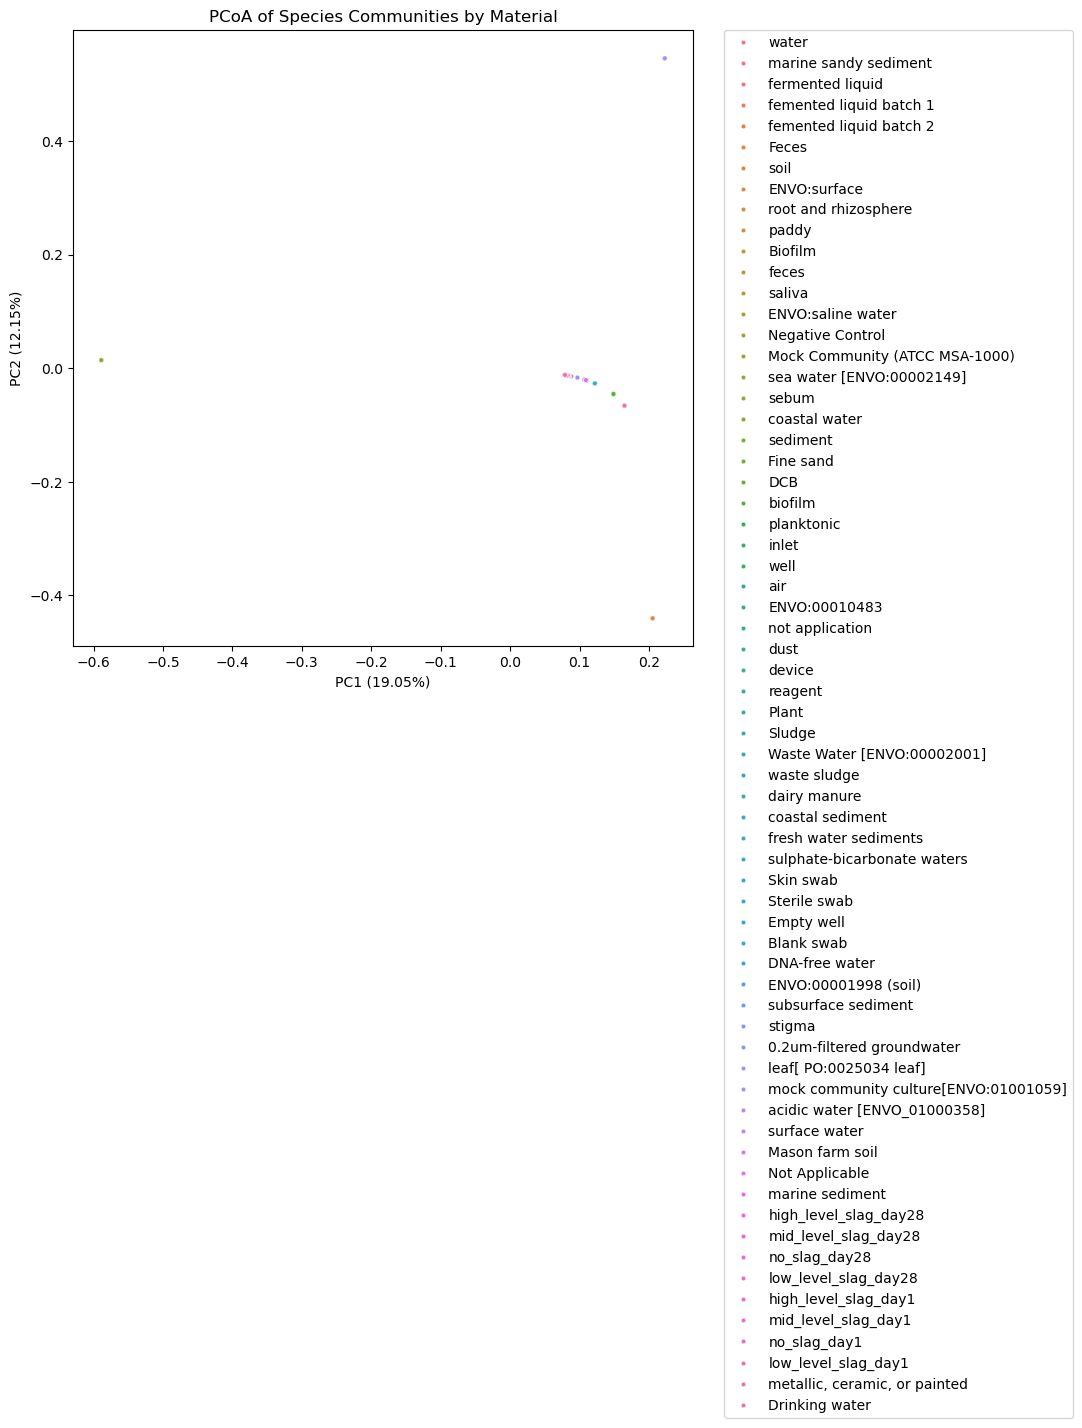

ValueError: One or more IDs in the distance matrix are not in the data frame.

In [53]:
import pandas as pd
from skbio.stats.distance import permanova
from skbio.stats.ordination import pcoa
from skbio.stats.distance import DistanceMatrix
from sklearn.metrics.pairwise import pairwise_distances
import seaborn as sns
import matplotlib.pyplot as plt


# --- Step A: Create a Community Matrix (samples vs. species) ---
community_matrix = pd.crosstab(analysis_df['#sampleid'], analysis_df['species'])

# --- BEST PRACTICE: Convert counts to binary (0 or 1) for Jaccard ---
binary_matrix = (community_matrix > 0).astype(int)

# --- Step B: Calculate Pairwise Distances ---
# THE FIX: Use .to_numpy() to convert the DataFrame to a NumPy array
jaccard_distances = pairwise_distances(binary_matrix.to_numpy(), metric='jaccard')
jaccard_distance_matrix = DistanceMatrix(jaccard_distances, ids=community_matrix.index)

# (The rest of the PCoA and PERMANOVA code will now work correctly)
# --- Step C: Perform and Visualize Principal Coordinates Analysis (PCoA) ---
pcoa_results = pcoa(jaccard_distance_matrix)
pcoa_df = pcoa_results.samples.iloc[:,:2] # Get the first two principal coordinates
pcoa_df.columns = ['PC1', 'PC2']
sample_info = analysis_df[['#sampleid', 'experiment_environment_material']].drop_duplicates().set_index('#sampleid')
pcoa_df = pcoa_df.join(sample_info)

# Create the plot as before
plt.figure(figsize=(8, 8)) # Use a square figure to make it look nice
ax = sns.scatterplot(data=pcoa_df, x='PC1', y='PC2', hue='experiment_environment_material', s=10)

# --- THE FIX: Move the legend outside the plot ---
# bbox_to_anchor places the legend based on coordinates of the plot area.
# (1.05, 1) places the top-left corner of the legend just outside
# the top-right corner of the plot.
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)


# Add titles and labels as before
plt.title('PCoA of Species Communities by Material')
plt.xlabel(f"PC1 ({pcoa_results.proportion_explained[0]:.2%})")
plt.ylabel(f"PC2 ({pcoa_results.proportion_explained[1]:.2%})")

# Adjust layout to make room for the legend
plt.tight_layout()
plt.show()

# --- Step D: Perform PERMANOVA Test ---
permanova_results = permanova(jaccard_distance_matrix, pcoa_df['experiment_environment_material'])
print("\n--- PERMANOVA Results ---")
print(permanova_results)

/opt/tmp/ipykernel_2051413/1695618899.py:11: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(jaccard_distances, method='average')


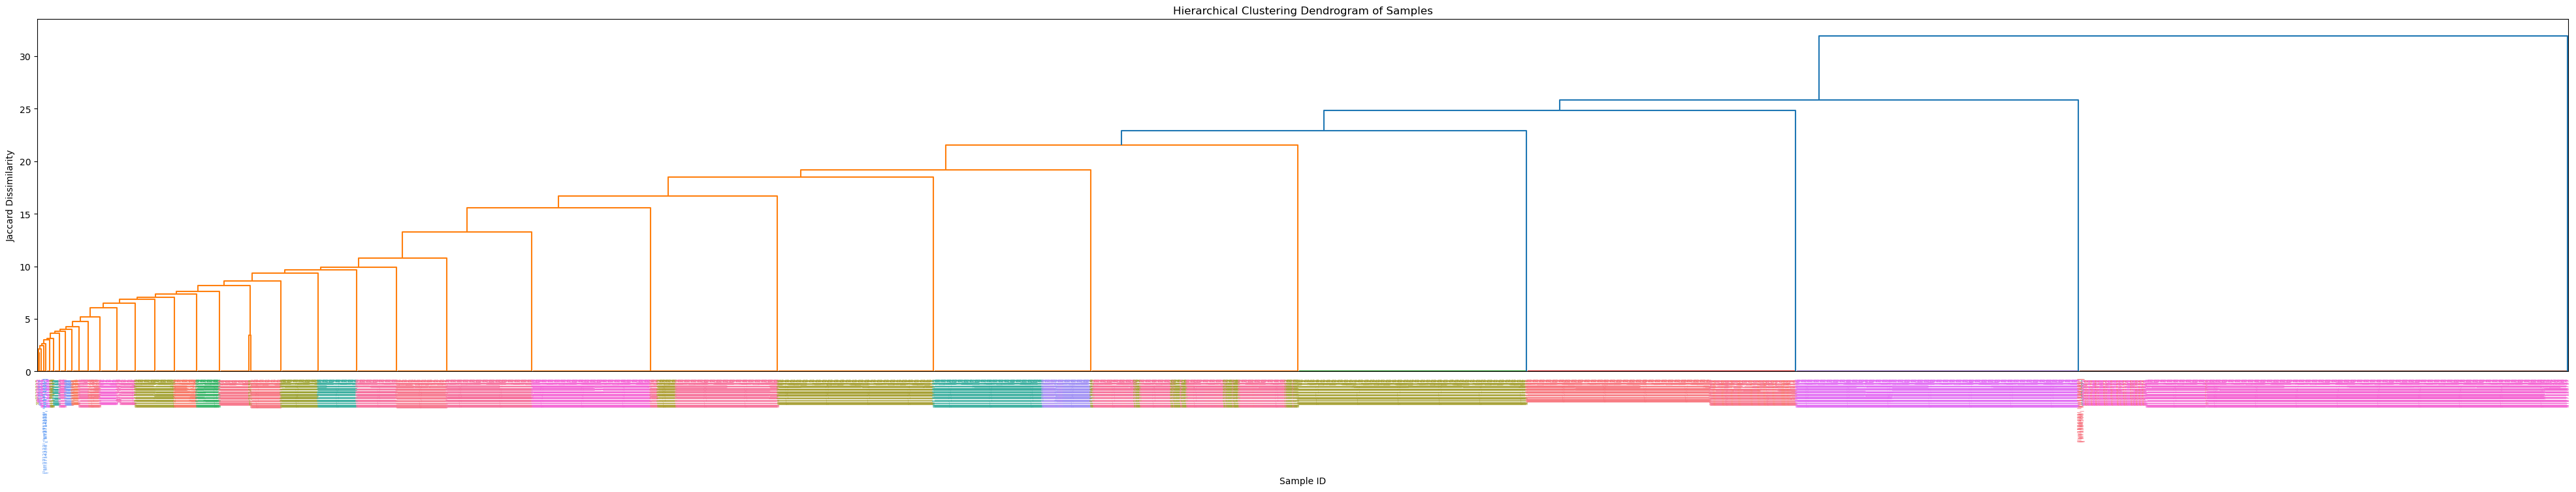

In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for color palettes
from sklearn.metrics.pairwise import pairwise_distances

# --- Step A: Perform Hierarchical Clustering ---
linked = linkage(jaccard_distances, method='average')

# --- Step B: Create a DYNAMIC color map for the labels ---
# THE FIX IS HERE:
# 1. Get a list of unique materials
unique_materials = sample_info['experiment_environment_material'].unique()
# 2. Create a color palette with exactly enough colors
palette = sns.color_palette('husl', n_colors=len(unique_materials))
# 3. Create a robust color map dictionary
material_map = dict(zip(unique_materials, palette))

# Now, map the materials to the new, complete color map
label_colors = sample_info['experiment_environment_material'].map(material_map)


# --- Step C: Plot the Dendrogram ---
plt.figure(figsize=(50, 7))
dendrogram(linked,
           orientation='top',
           labels=community_matrix.index.tolist(),
           distance_sort='descending',
           show_leaf_counts=True)

# Color the labels (this part will now work)
ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl in xlbls:
    lbl.set_color(label_colors[lbl.get_text()])

plt.title('Hierarchical Clustering Dendrogram of Samples')
plt.ylabel('Jaccard Dissimilarity')
plt.xlabel('Sample ID')
plt.show()